# GA Optimasi Posisi Object 2D COC Priority, Wall
## Rule
objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih
2. tidak overlap
3. bisa memperioritaskan bangunan di tengah, ring 1,2 dan seterunya hingga batas tepi dan tidak keluar dari 44x44
4. bisa melakukan cluster bangunan
5. Candidate wall tidak boleh berada di dalam footprint building.
6. program ini hanya untuk bangunan saja, adapun pagar dibuat setelah tata letak bangunan ada

Setiap objek/individual mempunyai posisi dan ukuran:
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat

## Contoh asli bangunan TH13

|	id	|	name	|	count	|	level	|	size	|	category	|	village	|
|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|
|	1000001	|	Town Hall	|	1	|	13	|	[4, 4]	|	Town Hall	|	home	|
|	1000014	|	Clan Castle	|	1	|	9	|	[3, 3]	|	Army	|	home	|
|	1000031	|	Eagle Artillery	|	1	|	4	|	[4, 4]	|	Defense	|	home	|
|	1000067	|	Scattershot	|	2	|	2	|	[3, 3]	|	Defense	|	home	|
|	1000027	|	Inferno Tower	|	3	|	6	|	[2, 2]	|	Defense	|	home	|
|	1000021	|	X-Bow	|	4	|	5	|	[3, 3]	|	Defense	|	home	|
|	1000012	|	Air Defense	|	4	|	9	|	[3, 3]	|	Defense	|	home	|
|	1000028	|	Air Sweeper	|	2	|	7	|	[2, 2]	|	Defense	|	home	|
|	1000009	|	Archer Tower	|	8	|	15	|	[3, 3]	|	Defense	|	home	|
|	1000000	|	Army Camp	|	4	|	11	|	[4, 4]	|	Army	|	home	|
|	1000006	|	Barracks	|	1	|	15	|	[3, 3]	|	Army	|	home	|
|	1000070	|	Blacksmith	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000032	|	Bomb Tower	|	2	|	6	|	[3, 3]	|	Defense	|	home	|
|	1000015	|	Builder's Hut	|	5	|	1	|	[2, 2]	|	Worker	|	home	|
|	1000008	|	Cannon	|	7	|	19	|	[3, 3]	|	Defense	|	home	|
|	1000026	|	Dark Barracks	|	1	|	10	|	[3, 3]	|	Army	|	home	|
|	1000023	|	Dark Elixir Drill	|	3	|	9	|	[3, 3]	|	Resource	|	home	|
|	1000024	|	Dark Elixir Storage	|	1	|	8	|	[3, 3]	|	Resource	|	home	|
|	1000029	|	Dark Spell Factory	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000002	|	Elixir Collector	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000003	|	Elixir Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000004	|	Gold Mine	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000005	|	Gold Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000093	|	Helper Hut	|	1	|	1	|	[3, 3]	|	Helper	|	home	|
|	1000071	|	Hero Hall	|	1	|	7	|	[4, 4]	|	Army	|	home	|
|	1000019	|	Hidden Tesla	|	5	|	9	|	[2, 2]	|	Defense	|	home	|
|	1000007	|	Laboratory	|	1	|	11	|	[3, 3]	|	Army	|	home	|
|	1000013	|	Mortar	|	4	|	12	|	[3, 3]	|	Defense	|	home	|
|	1000020	|	Spell Factory	|	1	|	7	|	[3, 3]	|	Army	|	home	|
|	1000010	|	Wall	|	300	|	14	|	[1, 1]	|	Wall	|	home	|
|	1000011	|	Wizard Tower	|	5	|	10	|	[3, 3]	|	Defense	|	home	|
|	1000059	|	Workshop	|	1	|	5	|	[4, 4]	|	Army	|	home	|


## Import

In [ ]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from PIL import Image

## Data village

In [ ]:
village = {
  "townhall_level": 13,
  "building_count": 393,
  "wall_count": 300,
  "map_size": 44,
  "buildings": [
    {
      "id": 1000001,
      "name": "Town Hall",
      "level": 13,
      "size": [4, 4],
      "category": "Town Hall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000014,
      "name": "Clan Castle",
      "level": 9,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000031,
      "name": "Eagle Artillery",
      "level": 4,
      "size": [4, 4],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000006,
      "name": "Barracks",
      "level": 15,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000070,
      "name": "Blacksmith",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000026,
      "name": "Dark Barracks",
      "level": 10,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000024,
      "name": "Dark Elixir Storage",
      "level": 8,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000029,
      "name": "Dark Spell Factory",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000093,
      "name": "Helper Hut",
      "level": 1,
      "size": [3, 3],
      "category": "Helper",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000071,
      "name": "Hero Hall",
      "level": 7,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000007,
      "name": "Laboratory",
      "level": 11,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000020,
      "name": "Spell Factory",
      "level": 7,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000059,
      "name": "Workshop",
      "level": 5,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    }
  ],
  "walls":[
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 9
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 10
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 11
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 12
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 13
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 14
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 15
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 16
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 17
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 18
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 19
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 20
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 21
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 22
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 23
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 24
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 25
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 26
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 27
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 28
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 29
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 30
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 31
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 32
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 33
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 34
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 35
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 36
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 37
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 38
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 39
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 40
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 41
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 42
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 43
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 44
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 45
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 46
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 47
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 48
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 49
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 50
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 51
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 52
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 53
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 54
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 55
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 56
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 57
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 58
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 59
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 60
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 61
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 62
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 63
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 64
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 65
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 66
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 67
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 68
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 69
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 70
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 71
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 72
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 73
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 74
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 75
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 76
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 77
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 78
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 79
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 80
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 81
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 82
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 83
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 84
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 85
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 86
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 87
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 88
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 89
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 90
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 91
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 92
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 93
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 94
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 95
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 96
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 97
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 98
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 99
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 100
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 101
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 102
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 103
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 104
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 105
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 106
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 107
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 108
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 109
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 110
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 111
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 112
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 113
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 114
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 115
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 116
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 117
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 118
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 119
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 120
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 121
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 122
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 123
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 124
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 125
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 126
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 127
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 128
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 129
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 130
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 131
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 132
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 133
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 134
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 135
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 136
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 137
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 138
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 139
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 140
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 141
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 142
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 143
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 144
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 145
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 146
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 147
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 148
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 149
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 150
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 151
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 152
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 153
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 154
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 155
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 156
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 157
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 158
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 159
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 160
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 161
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 162
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 163
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 164
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 165
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 166
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 167
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 168
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 169
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 170
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 171
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 172
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 173
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 174
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 175
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 176
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 177
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 178
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 179
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 180
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 181
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 182
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 183
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 184
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 185
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 186
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 187
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 188
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 189
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 190
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 191
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 192
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 193
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 194
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 195
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 196
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 197
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 198
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 199
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 200
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 201
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 202
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 203
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 204
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 205
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 206
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 207
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 208
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 209
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 210
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 211
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 212
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 213
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 214
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 215
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 216
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 217
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 218
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 219
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 220
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 221
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 222
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 223
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 224
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 225
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 226
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 227
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 228
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 229
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 230
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 231
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 232
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 233
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 234
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 235
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 236
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 237
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 238
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 239
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 240
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 241
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 242
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 243
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 244
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 245
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 246
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 247
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 248
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 249
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 250
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 251
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 252
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 253
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 254
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 255
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 256
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 257
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 258
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 259
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 260
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 261
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 262
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 263
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 264
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 265
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 266
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 267
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 268
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 269
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 270
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 271
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 272
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 273
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 274
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 275
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 276
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 277
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 278
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 279
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 280
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 281
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 282
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 283
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 284
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 285
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 286
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 287
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 288
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 289
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 290
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 291
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 292
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 293
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 294
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 295
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 296
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 297
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 298
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 299
    },
    {
      "id": 1000010,
      "name": "Wall",
      "level": 14,
      "size": [1, 1],
      "category": "Wall",
      "village": "home",
      "instance": 300
    }
  ]
}


## Parameter

In [ ]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 200          # Naikkan dari 50 ke 150 atau 200
GENERATIONS = 100              # Naikkan dari 100 ke 500+
TOURNAMENT_SIZE = 3 # populasi / tournament = populasi terbaik
MUTATION_RATE = 0.25           # Naikkan dari 0.1 ke 0.2 - 0.3

GRID_SIZE = 44

OVERLAP_PENALTY = 1000
BOUNDARY_PENALTY = 1000

BUILDINGS = village["buildings"] 
WALLS = village["walls"]
NUMBER_OF_OBJECTS = len(BUILDINGS)

# Priority Center
PRIORITY_BUILDING_IDS = [
    1000001,  # Town Hall
    # 1000014,  # Clan Castle
    # 1000067,  # Scattershot
    1000031, #Eagle Artillery
    1000027, #Inferno Tower
]
CENTER_RADIUS = 8              # Turunkan dari 15 ke 8 (agar benar-benar terkonsentrasi di pusat)
CENTER_REWARD_WEIGHT = 500     # Naikkan bobot reward agar bangunan prioritas berlomba-lomba ke tengah
CLEARANCE_PENALTY = 50         # Sesuaikan agar jarak antar bangunan lebih terjaga

MAX_WALLS = village["wall_count"]


In [ ]:
total_area = sum(
    building["size"][0] * building["size"][1]
    for building in BUILDINGS
)

print("Total building area:", total_area)
print("Map area:", GRID_SIZE * GRID_SIZE)

Total building area: 818
Map area: 1936


## Function

In [ ]:
# =========================================
# Center Radius
# =========================================
def random_center_position(size):

    width, height = size

    center_x = GRID_SIZE // 2
    center_y = GRID_SIZE // 2

    min_x = max(
        0,
        center_x - CENTER_RADIUS
    )

    max_x = min(
        GRID_SIZE - width,
        center_x + CENTER_RADIUS
    )

    min_y = max(
        0,
        center_y - CENTER_RADIUS
    )

    max_y = min(
        GRID_SIZE - height,
        center_y + CENTER_RADIUS
    )

    x = random.randint(min_x, max_x)
    y = random.randint(min_y, max_y)

    return (x, y)

# =========================================
# memperbaiki crossover
# =========================================
def repair(individual):

    repaired = [None] * NUMBER_OF_OBJECTS

    for i in range(NUMBER_OF_OBJECTS):

        position = individual[i]
        size = BUILDINGS[i]["size"]

        placed = [
            (
                repaired[j],
                BUILDINGS[j]["size"]
            )
            for j in range(i)
            if repaired[j] is not None
        ]

        if position is not None:

            if position_is_valid(
                position,
                size,
                placed
            ):
                repaired[i] = position
                continue

        # Jika posisi invalid, cari posisi baru
        new_position = find_valid_position(
            size,
            placed,
            center=(
                BUILDINGS[i]["id"]
                in PRIORITY_BUILDING_IDS
            )
        )

        if new_position is None:
            # fallback
            width, height = size

            new_position = (
                random.randint(
                    0,
                    GRID_SIZE - width
                ),
                random.randint(
                    0,
                    GRID_SIZE - height
                )
            )

        repaired[i] = new_position

    return repaired

# =========================================
# Pengecekan posisi agar tidak overlap ditengah
# =========================================
def position_is_valid(
    position,
    size,
    placed_buildings
):

    for other_position, other_size in placed_buildings:

        if is_overlap(
            position,
            size,
            other_position,
            other_size
        ):
            return False

    return True

def find_valid_position(
    size,
    placed_buildings,
    center=False,
    max_attempts=100
):

    for _ in range(max_attempts):

        if center:
            position = random_center_position(size)

        else:

            width, height = size

            x = random.randint(
                0,
                GRID_SIZE - width
            )

            y = random.randint(
                0,
                GRID_SIZE - height
            )

            position = (x, y)

        if position_is_valid(
            position,
            size,
            placed_buildings
        ):
            return position

    return None

In [ ]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    
def building_center(position, size):

    x, y = position
    width, height = size

    return (
        x + width / 2,
        y + height / 2
    )
   
def center_distance(position, size):

    x, y = building_center(
        position,
        size
    )

    center_x = GRID_SIZE / 2
    center_y = GRID_SIZE / 2

    return math.sqrt(
        (x - center_x) ** 2 +
        (y - center_y) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    return (
        x1 < x2 + w2 and
        x1 + w1 > x2 and
        y1 < y2 + h2 and
        y1 + h1 > y2
    )

# =========================================
# Agar bangunan tidak berdempetan
# =========================================
def is_too_close(
    pos1,
    size1,
    pos2,
    size2,
    clearance=1
):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    # Horizontal separation
    if x1 + w1 < x2:
        dx = x2 - (x1 + w1)

    elif x2 + w2 < x1:
        dx = x1 - (x2 + w2)

    else:
        dx = 0


    # Vertical separation
    if y1 + h1 < y2:
        dy = y2 - (y1 + h1)

    elif y2 + h2 < y1:
        dy = y1 - (y2 + h2)

    else:
        dy = 0


    if is_overlap(
        pos1,
        size1,
        pos2,
        size2
    ):
        return False


    min_distance = math.sqrt(
        dx ** 2 +
        dy ** 2
    )

    return min_distance < clearance

# =====================================
# Log dan kalkulasi fitness, fungsinya sama seperti fitness, tapi khusus untuk log
# =====================================
def calculate_fitness(individual):

    # =====================================
    # Counter
    # =====================================

    overlap_count = 0
    clearance_count = 0
    boundary_count = 0

    center_reward = 0

    # =====================================
    # Penalty
    # =====================================

    overlap_penalty = 0
    clearance_penalty = 0
    boundary_penalty = 0


    # =====================================
    # Boundary
    # =====================================

    for i, building in enumerate(BUILDINGS):

        x, y = individual[i]

        width, height = building["size"]

        if x < 0:
            boundary_count += 1
            boundary_penalty += BOUNDARY_PENALTY

        if y < 0:
            boundary_count += 1
            boundary_penalty += BOUNDARY_PENALTY

        if x + width > GRID_SIZE:
            boundary_count += 1
            boundary_penalty += BOUNDARY_PENALTY

        if y + height > GRID_SIZE:
            boundary_count += 1
            boundary_penalty += BOUNDARY_PENALTY


    # =====================================
    # Building relationship
    # =====================================

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            pos1 = individual[i]
            pos2 = individual[j]

            size1 = BUILDINGS[i]["size"]
            size2 = BUILDINGS[j]["size"]


            # -----------------------------
            # Overlap
            # -----------------------------

            if is_overlap(
                pos1,
                size1,
                pos2,
                size2
            ):

                overlap_count += 1
                overlap_penalty += OVERLAP_PENALTY


            # -----------------------------
            # Clearance
            # -----------------------------

            elif is_too_close(
                pos1,
                size1,
                pos2,
                size2,
                clearance=1
            ):

                clearance_count += 1
                clearance_penalty += CLEARANCE_PENALTY


    # =====================================
    # Center Priority
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            d = center_distance(
                individual[i],
                building["size"]
            )

            center_reward += (
                CENTER_REWARD_WEIGHT /
                (1 + d)
            )


    # =====================================
    # Total Fitness
    # =====================================

    total = (
        center_reward
        - overlap_penalty
        - clearance_penalty
        - boundary_penalty
    )


    # =====================================
    # Return Detail
    # =====================================

    return {
        "overlap_count": overlap_count,
        "clearance_count": clearance_count,
        "boundary_count": boundary_count,

        "overlap_penalty": overlap_penalty,
        "clearance_penalty": clearance_penalty,
        "boundary_penalty": boundary_penalty,

        "center_reward": center_reward,

        "total": total
    }

def print_fitness_detail(individual):

    result = calculate_fitness(individual)

    print(
        f"Overlap={result['overlap_count']} | "
        f"Clearance={result['clearance_count']} | "
        f"Boundary={result['boundary_count']} | "
        f"Center={result['center_reward']:.2f} | "
        f"Total={result['total']:.2f}"
    )

# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):

    penalty = 0
    center_reward = 0
    clearance_penalty = 0

    # =====================================
    # Boundary
    # =====================================

    for i, building in enumerate(BUILDINGS):

        x, y = individual[i]

        width, height = building["size"]

        if x < 0:
            penalty += BOUNDARY_PENALTY

        if y < 0:
            penalty += BOUNDARY_PENALTY

        if x + width > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if y + height > GRID_SIZE:
            penalty += BOUNDARY_PENALTY


    # =====================================
    # Building relationship
    # =====================================

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            pos1 = individual[i]
            pos2 = individual[j]

            size1 = BUILDINGS[i]["size"]
            size2 = BUILDINGS[j]["size"]

            # Overlap
            if is_overlap(
                pos1,
                size1,
                pos2,
                size2
            ):
                penalty += OVERLAP_PENALTY

            # Clearance
            elif is_too_close(
                pos1,
                size1,
                pos2,
                size2,
                clearance=1
            ):
                clearance_penalty += CLEARANCE_PENALTY


    # =====================================
    # Center Priority
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            d = center_distance(
                individual[i],
                building["size"]
            )

            center_reward += (
                CENTER_REWARD_WEIGHT /
                (1 + d)
            )

    result = calculate_fitness(individual)
    
    return result["total"]


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = [None] * NUMBER_OF_OBJECTS

    placed_buildings = []

    # =====================================
    # 1. PRIORITY BUILDINGS
    # =====================================

    priority_indices = []

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            priority_indices.append(i)


    # =====================================
    # 2. PLACE PRIORITY
    # =====================================

    for i in priority_indices:

        building = BUILDINGS[i]
        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=True
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    # =====================================
    # 3. PLACE OTHER BUILDINGS
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if individual[i] is not None:
            continue

        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=False
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    return individual

In [ ]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

# def selection(population):
#     population_sorted = sorted(
#         population,
#         key=fitness,
#         reverse=True
#     )

#     # Ambil 50% terbaik
#     return population_sorted[:POPULATION_SIZE // 2]
def selection(population):

    parents = []

    for _ in range(POPULATION_SIZE // 2):

        tournament = random.sample(
            population,
            TOURNAMENT_SIZE
        )

        winner = max(
            tournament,
            key=fitness
        )

        parents.append(winner)

    return parents

# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    point = random.randint(
        1,
        NUMBER_OF_OBJECTS - 1
    )

    child1 = (
        parent1[:point]
        + parent2[point:]
    )

    child2 = (
        parent2[:point]
        + parent1[point:]
    )

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):
    mutated = individual.copy()
    
    # Buat daftar bangunan yang sudah terpasang selain bangunan yang sedang dimutasi
    for i in range(NUMBER_OF_OBJECTS):
        if random.random() < MUTATION_RATE:
            size = BUILDINGS[i]["size"]
            
            # Kumpulkan posisi bangunan lain
            placed = [
                (mutated[j], BUILDINGS[j]["size"]) 
                for j in range(NUMBER_OF_OBJECTS) if j != i and mutated[j] is not None
            ]
            
            # Cari posisi valid baru di sekitar area lama atau secara acak
            new_pos = find_valid_position(size, placed, center=(BUILDINGS[i]["id"] in PRIORITY_BUILDING_IDS))
            
            if new_pos is not None:
                mutated[i] = new_pos
                
    return mutated




## Run GA

In [ ]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )


    # -----------------------------
    # Print fitness
    # -----------------------------

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f}"
    )


    # -----------------------------
    # Detail setiap 5 generasi
    # -----------------------------

    if (generation + 1) % 5 == 0:

        print_fitness_detail(best)


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = [best] + parents.copy()  # simpan individu terbaik apa adanya


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        # REPARASI ANAK DI SINI AGAR TIDAK OVERLAP
        child1 = repair(child1)
        child2 = repair(child2)

        child1 = mutation(child1)
        child2 = mutation(child2)

        # REPARASI KEMBALI SETELAH MUTASI (Opsional tapi aman)
        child1 = repair(child1)
        child2 = repair(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)

    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

fitness_values = [
    fitness(individual)
    for individual in population
]

best_fitness = max(fitness_values)
average_fitness = sum(fitness_values) / len(fitness_values)
worst_fitness = min(fitness_values)

print(
    f"Generation {generation + 1:03d} | "
    f"Best = {best_fitness:.2f} | "
    f"Average = {average_fitness:.2f} | "
    f"Worst = {worst_fitness:.2f}"
)

print("="*50)
print("POPULATION_SIZE = ", POPULATION_SIZE)
print("GENERATIONS = ", GENERATIONS)
print("Fitness  :", fitness(best))
print("best = ", best)
print("Build with love 🥰")


RuntimeError: Gagal menempatkan Workshop instance 1

## Visualisasi

In [ ]:
# best = [(21, 20), (34, 4), (25, 30), (12, 21), (19, 39), (25, 23), (10, 26), (9, 15), (27, 38), (33, 15), (1, 20), (21, 3), (5, 11), (41, 29), (35, 35), (1, 3), (23, 25), (36, 16), (27, 12), (0, 15), (15, 17), (0, 10), (25, 19), (39, 39), (4, 24), (32, 35), (12, 30), (11, 36), (26, 3), (35, 31), (35, 12), (6, 19), (22, 27), (16, 37), (35, 20), (27, 8), (15, 20), (17, 23), (18, 16), (12, 25), (33, 26), (0, 29), (40, 12), (41, 22), (14, 9), (39, 15), (14, 0), (25, 34), (30, 20), (7, 33), (16, 32), (1, 39), (18, 1), (9, 8), (26, 16), (41, 6), (9, 21), (21, 8), (16, 6), (14, 14), (29, 16), (32, 1), (37, 6), (3, 14), (22, 12), (38, 20), (8, 0), (30, 11), (30, 8), (22, 36), (31, 4), (39, 0), (4, 34), (9, 29), (35, 40), (21, 15), (2, 6), (29, 34), (30, 37), (34, 7), (33, 38), (1, 33), (8, 39), (15, 41), (27, 22), (39, 32), (14, 3), (41, 35), (4, 29), (39, 9), (29, 27), (33, 23), (16, 27)]

# GENERATIONS =  100
# Fitness  : -618.6933124588603
# best =  [(14, 28), (7, 31), (28, 13), (31, 34), (19, 17), (33, 8), (11, 21), (11, 24), (21, 5), (19, 11), (3, 22), (4, 5), (19, 29), (24, 29), (15, 36), (7, 9), (41, 6), (41, 23), (0, 27), (16, 12), (14, 9), (14, 17), (2, 17), (7, 19), (34, 19), (34, 33), (6, 39), (36, 7), (33, 27), (15, 22), (12, 13), (30, 38), (7, 35), (39, 26), (28, 10), (41, 2), (22, 2), (17, 40), (24, 37), (24, 23), (15, 1), (4, 26), (13, 5), (3, 30), (29, 29), (28, 0), (41, 18), (31, 3), (2, 35), (32, 41), (39, 41), (40, 14), (37, 0), (30, 19), (0, 14), (11, 33), (35, 23), (28, 34), (23, 34), (25, 4), (3, 0), (0, 7), (27, 24), (9, 4), (30, 7), (0, 32), (41, 9), (8, 13), (30, 23), (19, 1), (13, 40), (35, 3), (24, 18), (17, 5), (37, 18), (32, 14), (3, 11), (36, 42), (18, 15), (9, 2), (33, 0), (41, 34), (41, 29), (24, 13), (5, 15), (36, 39), (3, 40), (27, 7), (19, 34), (0, 23), (10, 29), (40, 38), (21, 40)]


# POPULATION_SIZE = 50
# GENERATIONS = 250
# Fitness  : -1030.5458622177373
# best = [(30, 31), (28, 3), (36, 28), (33, 23), (10, 34), (12, 29), (30, 21), (37, 11), (4, 5), (15, 1), (13, 19), (18, 27), (24, 12), (29, 25), (5, 36), (26, 21), (40, 22), (32, 6), (12, 11), (9, 3), (24, 39), (16, 35), (14, 6), (10, 8), (21, 32), (18, 41), (2, 9), (36, 36), (30, 15), (5, 17), (2, 41), (19, 21), (1, 33), (26, 0), (13, 32), (35, 20), (24, 1), (9, 24), (2, 37), (20, 15), (20, 11), (39, 1), (13, 25), (41, 15), (25, 5), (7, 0), (11, 0), (14, 28), (24, 18), (8, 29), (4, 25), (23, 21), (38, 16), (31, 8), (7, 9), (2, 29), (18, 31), (8, 37), (38, 33), (31, 0), (40, 12), (14, 22), (24, 36), (15, 9), (32, 40), (28, 9), (27, 15), (9, 16), (21, 8), (30, 28), (28, 36), (19, 3), (40, 30), (32, 36), (18, 18), (25, 30), (33, 3), (15, 15), (42, 9), (9, 13), (6, 22), (0, 3), (0, 15), (32, 20), (38, 6), (13, 39), (40, 36), (41, 39), (19, 24), (1, 21), (5, 29), (27, 40), (19, 37)]

# POPULATION_SIZE =  200
# GENERATIONS =  100
# Fitness  : -1059.3788538613517
best =  [(24, 16), (32, 41), (16, 30), (37, 0), (41, 22), (21, 21), (29, 26), (17, 17), (28, 0), (20, 32), (4, 7), (2, 34), (12, 3), (37, 4), (24, 34), (0, 19), (25, 41), (24, 1), (6, 35), (18, 27), (12, 9), (41, 3), (8, 22), (40, 7), (41, 11), (27, 40), (10, 30), (40, 33), (13, 38), (35, 40), (37, 25), (41, 27), (22, 23), (37, 29), (0, 7), (39, 19), (25, 24), (27, 38), (16, 5), (32, 0), (18, 35), (39, 14), (1, 12), (34, 20), (16, 11), (21, 11), (5, 3), (12, 18), (33, 8), (8, 7), (20, 39), (26, 13), (28, 8), (24, 7), (35, 16), (9, 35), (29, 23), (0, 15), (37, 21), (30, 34), (22, 28), (20, 18), (12, 0), (7, 26), (5, 11), (7, 0), (9, 13), (32, 4), (39, 38), (4, 18), (0, 41), (1, 2), (29, 20), (16, 7), (30, 28), (6, 39), (10, 4), (14, 16), (3, 28), (33, 26), (29, 13), (37, 34), (8, 18), (17, 24), (3, 24), (20, 14), (23, 37), (31, 12), (13, 21), (41, 0), (6, 30), (27, 30), (19, 0)]


# POPULATION_SIZE =  150
# GENERATIONS =  100
# Fitness  : -1072.920960401988
# best =  [(20, 20), (10, 41), (27, 28), (1, 12), (6, 37), (20, 16), (16, 22), (22, 24), (24, 29), (9, 9), (27, 8), (14, 30), (26, 0), (36, 32), (27, 41), (5, 41), (41, 38), (0, 7), (37, 41), (2, 0), (31, 18), (34, 28), (17, 37), (11, 23), (26, 12), (6, 28), (24, 36), (9, 0), (39, 14), (10, 35), (29, 4), (37, 29), (39, 8), (30, 21), (1, 24), (34, 26), (14, 10), (0, 20), (17, 29), (10, 5), (41, 34), (18, 40), (8, 16), (19, 1), (5, 0), (26, 18), (35, 9), (33, 34), (1, 4), (32, 4), (37, 25), (10, 27), (32, 13), (0, 15), (26, 3), (39, 0), (36, 4), (41, 27), (41, 5), (31, 30), (4, 5), (26, 22), (13, 18), (36, 13), (14, 41), (15, 1), (4, 15), (22, 6), (37, 20), (41, 24), (23, 16), (1, 34), (18, 11), (20, 30), (0, 38), (29, 34), (3, 22), (31, 42), (37, 0), (3, 38), (5, 20), (33, 0), (2, 30), (16, 33), (9, 20), (41, 30), (15, 15), (7, 12), (12, 14), (31, 9), (34, 40), (6, 24), (40, 19)]


# POPULATION_SIZE =  50
# GENERATIONS = 
# Fitness  : -1046.7205283700187
# best =  [(25, 29), (0, 31), (9, 2), (8, 16), (39, 19), (2, 39), (6, 14), (42, 15), (0, 28), (11, 35), (8, 22), (9, 39), (32, 17), (24, 40), (38, 37), (34, 13), (13, 4), (12, 0), (31, 8), (12, 41), (2, 41), (26, 16), (22, 37), (17, 15), (11, 6), (13, 27), (4, 2), (22, 24), (18, 31), (35, 7), (22, 29), (32, 41), (6, 10), (41, 31), (34, 27), (13, 13), (11, 19), (18, 24), (20, 6), (5, 37), (37, 41), (5, 19), (40, 9), (32, 38), (17, 6), (40, 25), (14, 21), (28, 34), (31, 26), (0, 15), (11, 9), (10, 13), (26, 20), (30, 5), (2, 10), (38, 22), (8, 29), (17, 9), (36, 30), (3, 24), (7, 25), (13, 15), (29, 30), (16, 12), (5, 33), (23, 4), (17, 27), (22, 9), (16, 1), (25, 0), (26, 9), (37, 25), (41, 1), (15, 40), (0, 0), (17, 20), (36, 38), (38, 2), (30, 41), (2, 36), (30, 14), (15, 33), (34, 34), (20, 1), (32, 22), (34, 3), (27, 4), (27, 26), (25, 33), (1, 3), (16, 37), (2, 20), (28, 37)]

# POPULATION_SIZE =  50
# GENERATIONS =  300
# Fitness  : -1073.6428230819286
# best =  [(30, 13), (39, 2), (19, 8), (3, 5), (2, 32), (21, 15), (12, 33), (30, 27), (15, 4), (29, 2), (0, 17), (12, 11), (11, 14), (27, 34), (35, 31), (16, 33), (11, 29), (35, 5), (31, 38), (36, 35), (13, 40), (10, 0), (2, 23), (18, 19), (0, 3), (4, 8), (31, 18), (15, 9), (36, 10), (26, 5), (37, 14), (7, 41), (35, 19), (35, 2), (23, 18), (19, 16), (11, 27), (25, 30), (0, 0), (18, 36), (38, 30), (5, 19), (20, 24), (27, 19), (0, 13), (0, 40), (29, 22), (22, 0), (32, 24), (37, 23), (22, 36), (26, 1), (14, 28), (38, 6), (41, 9), (10, 23), (27, 39), (24, 27), (7, 26), (3, 40), (8, 9), (40, 22), (2, 29), (40, 37), (12, 7), (23, 6), (23, 21), (24, 11), (6, 1), (13, 23), (7, 13), (7, 23), (2, 36), (13, 1), (30, 9), (5, 36), (33, 5), (10, 39), (15, 37), (2, 26), (4, 13), (36, 38), (11, 18), (0, 6), (23, 14), (39, 19), (24, 41), (26, 15), (20, 39), (15, 15), (41, 31), (17, 30), (6, 4)]

# POPULATION_SIZE =  150
# GENERATIONS =  100
# Fitness  : -1136.2363034284224
# best =  [(16, 22), (36, 36), (22, 16), (18, 14), (39, 14), (21, 21), (20, 18), (17, 27), (40, 36), (15, 13), (17, 3), (17, 36), (12, 18), (5, 33), (8, 3), (30, 3), (18, 32), (15, 33), (32, 36), (0, 1), (7, 12), (36, 4), (3, 37), (25, 11), (0, 10), (28, 28), (10, 34), (7, 40), (25, 39), (39, 40), (21, 12), (41, 18), (25, 6), (33, 31), (26, 28), (1, 36), (42, 14), (33, 4), (29, 14), (32, 23), (31, 17), (1, 14), (22, 25), (20, 37), (4, 8), (36, 40), (40, 0), (14, 27), (21, 3), (11, 4), (12, 9), (16, 7), (41, 29), (16, 18), (39, 7), (5, 0), (1, 22), (32, 41), (0, 6), (22, 40), (24, 22), (41, 26), (21, 9), (29, 8), (9, 26), (37, 25), (34, 17), (5, 26), (29, 35), (39, 32), (23, 34), (12, 39), (36, 8), (1, 27), (29, 32), (21, 29), (32, 20), (26, 36), (7, 37), (13, 25), (41, 10), (1, 41), (1, 32), (0, 17), (4, 14), (28, 22), (30, 0), (5, 3), (36, 12), (10, 0), (11, 15), (14, 30), (25, 0)]

# POPULATION_SIZE =  150
# GENERATIONS =  150
# Fitness  : -1323.8755142650111
# best =  [(20, 20), (12, 7), (24, 23), (25, 13), (27, 35), (17, 22), (20, 17), (22, 17), (19, 13), (2, 8), (29, 8), (29, 20), (3, 31), (31, 15), (9, 20), (41, 9), (5, 36), (33, 0), (8, 41), (36, 13), (33, 10), (38, 22), (30, 26), (18, 41), (6, 11), (37, 26), (5, 2), (40, 32), (18, 26), (3, 16), (11, 4), (34, 17), (33, 25), (22, 1), (0, 28), (2, 5), (7, 32), (29, 13), (42, 17), (8, 15), (40, 27), (33, 3), (1, 39), (18, 38), (7, 6), (27, 0), (18, 31), (9, 25), (12, 12), (18, 0), (31, 30), (35, 29), (30, 37), (41, 20), (11, 38), (14, 39), (21, 7), (32, 7), (9, 30), (23, 35), (1, 35), (5, 21), (20, 34), (22, 40), (40, 12), (34, 36), (37, 35), (38, 6), (38, 0), (16, 8), (13, 17), (10, 0), (15, 12), (38, 17), (0, 20), (23, 27), (2, 1), (41, 42), (17, 18), (25, 10), (0, 26), (38, 40), (24, 31), (22, 11), (25, 6), (27, 31), (29, 41), (12, 21), (4, 27), (25, 19), (9, 11), (35, 7), (34, 21)]



NameError: name 'fitness' is not defined

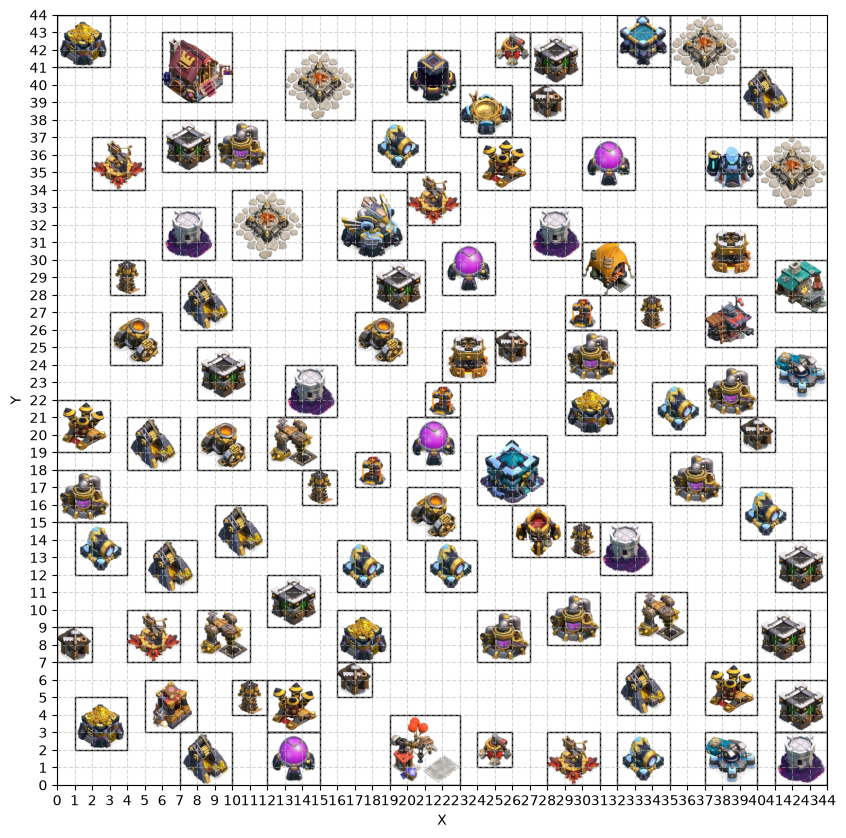

In [9]:

# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(best):
  bld = BUILDINGS[i]
  width, height = bld["size"]
  name = bld["name"]
  bld_id = bld["id"]
  level = bld["level"]

  rectangle = Rectangle(
      (x, y), width, height, fill=False, linewidth=1, edgecolor="black"
  )
  ax.add_patch(rectangle)

  folder_name_suffix = name.lower().replace(" ", "_")
  folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

  file_prefix = name.replace(" ", "_")
  img_filename = f"{file_prefix}{level}.webp"
  img_path = os.path.join(folder_path, img_filename)

  try:
    if os.path.exists(img_path):
      img = Image.open(img_path)
      ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
    else:
      print(f"Gambar tidak ditemukan: {img_path}")
  except Exception as e:
    print(f"Gagal memuat gambar {name}: {e}")

#   ax.text(
#       x + width / 2,
#       y + height / 2,
#       f"{name}\n(Lvl {level})",
#       ha="center",
#       va="center",
#       fontsize=5,
#       color="white",
#       weight="bold",
#       bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1),
#   )

# =========================================
# Map
# =========================================

# Pastikan GRID_SIZE sudah terdefinisi di kode Anda (misal: 44)
GRID_SIZE = village.get("map_size", 44)

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(f"COC Base Optimization\nFitness = {fitness(best):.2f}")

plt.show()

## Result Building

# GA WALL

## Import Wall

In [10]:
# Wall
BUILDING_CELL = 1
WALL_CANDIDATE_CELL = 2
WALL_DISTANCE = 1

# Wall Connector
GAP_WALL_SCORE = 100
NORMAL_WALL_SCORE = 10

MAX_WALLS = 300

## Function

In [11]:
def create_occupancy_grid():

    grid = [
        [0 for _ in range(GRID_SIZE)]
        for _ in range(GRID_SIZE)
    ]

    return grid

# =========================================
# 3. Mengisi Building ke Occupancy Grid
# =========================================

def place_buildings_on_grid(
    grid,
    buildings,
    positions
):

    for i, building in enumerate(buildings):

        x, y = positions[i]

        width, height = building["size"]

        for dy in range(height):

            for dx in range(width):

                grid[y + dy][x + dx] = BUILDING_CELL

    return grid

# =========================================
# Cek koordinat dalam map
# =========================================

def is_inside_grid(x, y):

    return (
        0 <= x < GRID_SIZE and
        0 <= y < GRID_SIZE
    )

# =========================================
# Tetangga Building
# =========================================

def get_building_neighbors(grid, x, y):

    neighbors = []

    directions = [
        (0, 1),   # atas
        (0, -1),  # bawah
        (-1, 0),  # kiri
        (1, 0)    # kanan
    ]

    for dx, dy in directions:

        nx = x + dx
        ny = y + dy

        if is_inside_grid(nx, ny):

            if grid[ny][nx] == BUILDING_CELL:
                neighbors.append((nx, ny))

    return neighbors    

# =========================================
# Deteksi Gap Wall
# =========================================

def is_between_buildings(grid, x, y):

    # Horizontal
    left = (x - 1, y)
    right = (x + 1, y)

    if (
        is_inside_grid(*left)
        and is_inside_grid(*right)
        and grid[left[1]][left[0]] == BUILDING_CELL
        and grid[right[1]][right[0]] == BUILDING_CELL
    ):
        return True

    # Vertical
    top = (x, y + 1)
    bottom = (x, y - 1)

    if (
        is_inside_grid(*top)
        and is_inside_grid(*bottom)
        and grid[top[1]][top[0]] == BUILDING_CELL
        and grid[bottom[1]][bottom[0]] == BUILDING_CELL
    ):
        return True

    return False

# =========================================
# Score Candidate Wall
# =========================================

def score_wall_candidate(grid, x, y):

    score = 0

    neighbors = get_building_neighbors(
        grid,
        x,
        y
    )

    # -------------------------------------
    # 1. Gap antara dua building
    # -------------------------------------

    if is_between_buildings(grid, x, y):

        score += GAP_WALL_SCORE

    # -------------------------------------
    # 2. Banyak building di sekitar
    # -------------------------------------

    score += len(neighbors) * 10

    # -------------------------------------
    # 3. Candidate biasa
    # -------------------------------------

    if len(neighbors) > 0:

        score += NORMAL_WALL_SCORE

    return score 

# =========================================
# Cek koneksi Wall
# =========================================

def get_wall_neighbors(position):

    x, y = position

    return [
        (x + 1, y),
        (x - 1, y),
        (x, y + 1),
        (x, y - 1)
    ]

# =========================================
# Wall Connector
# =========================================
def connect_walls(
    grid,
    candidate_walls,
    max_walls=MAX_WALLS
):

    selected_walls = set()

    remaining = set(candidate_walls)

    # -------------------------------------
    # Cari candidate dengan score tertinggi
    # -------------------------------------

    scored_candidates = []

    for x, y in candidate_walls:

        score = score_wall_candidate(
            grid,
            x,
            y
        )

        scored_candidates.append(
            ((x, y), score)
        )

    scored_candidates.sort(
        key=lambda item: item[1],
        reverse=True
    )

    # -------------------------------------
    # Seed pertama
    # -------------------------------------

    if not scored_candidates:
        return selected_walls

    seed = scored_candidates[0][0]

    selected_walls.add(seed)
    remaining.remove(seed)

    # -------------------------------------
    # Grow wall
    # -------------------------------------

    while len(selected_walls) < max_walls:

        connected_candidates = []

        for candidate in remaining:

            neighbors = get_wall_neighbors(
                candidate
            )

            # Candidate harus bersebelahan
            # dengan wall yang sudah dipilih
            if any(
                neighbor in selected_walls
                for neighbor in neighbors
            ):

                x, y = candidate

                score = score_wall_candidate(
                    grid,
                    x,
                    y
                )

                connected_candidates.append(
                    (candidate, score)
                )

        # Tidak ada candidate yang
        # bisa melanjutkan koneksi
        if not connected_candidates:
            break

        # Pilih candidate terbaik
        connected_candidates.sort(
            key=lambda item: item[1],
            reverse=True
        )

        selected = connected_candidates[0][0]

        selected_walls.add(selected)
        remaining.remove(selected)

    return selected_walls

# =========================================
# 5. Generate Candidate Wall
# =========================================

def generate_candidate_walls(grid):

    candidates = set()

    for y in range(GRID_SIZE):

        for x in range(GRID_SIZE):

            # Bukan building
            if grid[y][x] != BUILDING_CELL:
                continue

            # Cek 8 arah
            for dy in range(-WALL_DISTANCE, WALL_DISTANCE + 1):

                for dx in range(-WALL_DISTANCE, WALL_DISTANCE + 1):

                    # Jangan cek cell building itu sendiri
                    if dx == 0 and dy == 0:
                        continue

                    nx = x + dx
                    ny = y + dy

                    # Harus berada dalam grid
                    if not is_inside_grid(nx, ny):
                        continue

                    # Tidak boleh berada di atas building
                    if grid[ny][nx] == BUILDING_CELL:
                        continue

                    candidates.add((nx, ny))

    return candidates

# =========================================
# 6. Generate Occupancy
# =========================================

occupancy_grid = create_occupancy_grid()

occupancy_grid = place_buildings_on_grid(
    occupancy_grid,
    BUILDINGS,
    best
)



    

## Run Wall

Building count : 93
Wall count : 300
Candidate walls : 834
Candidate data : {(7, 17), (15, 30), (26, 30), (26, 39), (19, 9), (0, 5), (40, 41), (19, 18), (21, 37), (0, 14), (11, 23), (33, 20), (10, 27), (33, 29), (4, 2), (34, 3), (22, 10), (34, 12), (25, 43), (3, 6), (3, 15), (14, 15), (14, 24), (22, 37), (14, 33), (3, 33), (3, 42), (15, 7), (14, 42), (18, 3), (38, 18), (7, 21), (27, 8), (40, 27), (8, 4), (19, 4), (11, 0), (6, 34), (29, 36), (0, 9), (11, 9), (41, 10), (6, 43), (41, 19), (33, 15), (41, 37), (25, 20), (33, 33), (2, 27), (25, 29), (10, 40), (34, 7), (3, 1), (37, 3), (34, 16), (3, 10), (34, 25), (3, 19), (3, 37), (15, 2), (26, 2), (14, 37), (36, 34), (15, 11), (7, 7), (26, 20), (17, 39), (18, 16), (40, 22), (6, 29), (40, 31), (21, 27), (6, 38), (21, 36), (25, 6), (10, 17), (33, 19), (41, 32), (25, 15), (10, 26), (33, 28), (2, 22), (33, 37), (25, 33), (34, 11), (2, 40), (3, 5), (37, 7), (22, 27), (3, 23), (14, 32), (36, 29), (15, 6), (26, 6), (28, 25), (18, 2), (17, 34), (9,

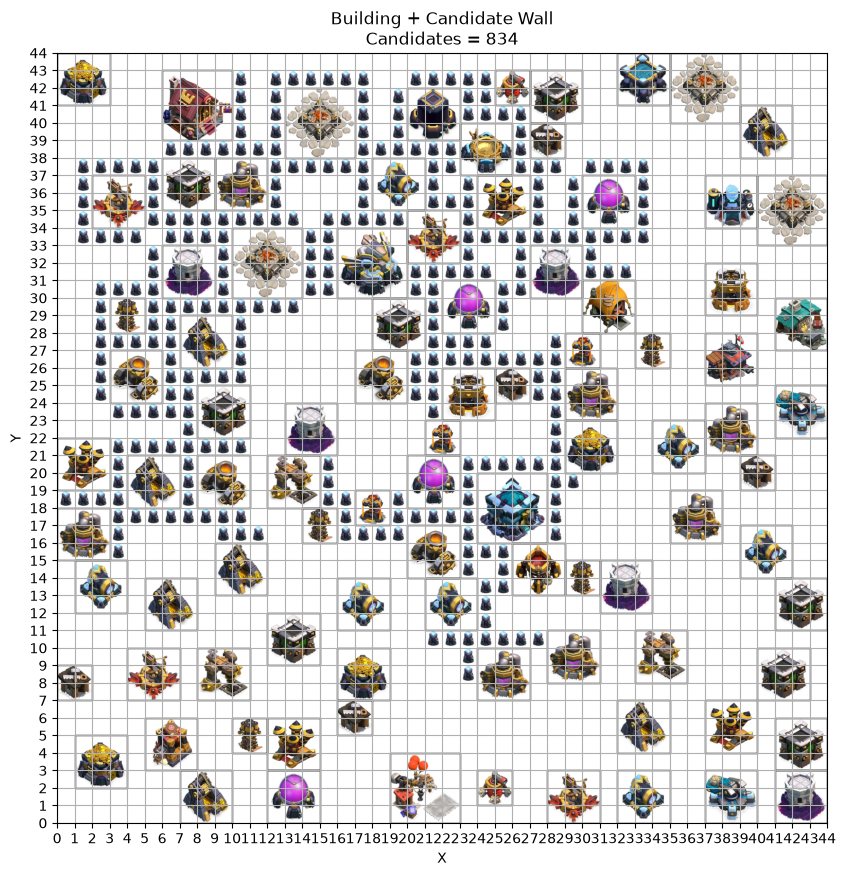

In [12]:
# =========================================
# Generate Candidate Wall
# =========================================

candidate_walls = generate_candidate_walls(
    occupancy_grid
)

print("Building count :", len(BUILDINGS))
print("Wall count :", len(WALLS))

print("Candidate walls :", len(candidate_walls))
print("Candidate data :", candidate_walls)

# =========================================
# Generate Connected Wall
# =========================================

wall_positions = connect_walls(
    occupancy_grid,
    candidate_walls,
    max_walls=MAX_WALLS
)

print("wall_positions  :", wall_positions)
print("Selected walls  :", len(wall_positions))


# =========================================
# 7. Visualisasi Candidate Wall
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))


# =========================================
# Building
# =========================================

for i, (x, y) in enumerate(best):
  bld = BUILDINGS[i]
  width, height = bld["size"]
  name = bld["name"]
  bld_id = bld["id"]
  level = bld["level"]

  rectangle = Rectangle(
      (x, y), width, height, fill=False, linewidth=1, edgecolor="black"
  )
  ax.add_patch(rectangle)

  folder_name_suffix = name.lower().replace(" ", "_")
  folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

  file_prefix = name.replace(" ", "_")
  img_filename = f"{file_prefix}{level}.webp"
  img_path = os.path.join(folder_path, img_filename)

  try:
    if os.path.exists(img_path):
      img = Image.open(img_path)
      ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
    else:
      print(f"Gambar tidak ditemukan: {img_path}")
  except Exception as e:
    print(f"Gagal memuat gambar {name}: {e}")

#   ax.text(
#       x + width / 2,
#       y + height / 2,
#       f"{name}\n(Lvl {level})",
#       ha="center",
#       va="center",
#       fontsize=5,
#       color="white",
#       weight="bold",
#       bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1),
#   )



# =========================================
# Candidate Wall
# =========================================

# for x, y in candidate_walls:

#     rectangle = Rectangle(
#         (x, y),
#         1,
#         1,
#         fill=True,
#         facecolor='#a69494',
#         edgecolor='black',
#         linewidth=1
#     )

#     ax.add_patch(rectangle)

# =========================================
# Selected Wall
# =========================================

for x, y in wall_positions:
    wall = WALLS[0]
    level = wall["level"]
    
    wall_folder_path = f"../../../assets/buildings/1000010_wall"

    wall_img_filename = f"Wall_{level}.webp"
    wall_img_path = os.path.join(wall_folder_path, wall_img_filename)

    try:
        if os.path.exists(wall_img_path):
            img = Image.open(wall_img_path)
            ax.imshow(img, extent=(x, x + 1, y, y + 1), aspect="auto")
        else:
            rectangle = Rectangle(
                (x, y),
                1,
                1,
                fill=True,
                facecolor="#555555",
                edgecolor="black",
                linewidth=1
            )
            ax.add_patch(rectangle)
            
            print(f"Gambar tidak ditemukan: {wall_img_path}")
    except Exception as e:
        print(f"Gagal memuat gambar Wall: {e}")

# =========================================
# Grid
# =========================================

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True)

ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(
    f"Building + Candidate Wall\n"
    f"Candidates = {len(candidate_walls)}"
)
plt.show()




## Result